In [17]:
import numpy as np
import pandas as pd
# import yfinance as yf
import matplotlib.pyplot as plt
from tqdm import tqdm
from hmmlearn.hmm import GMMHMM
from sklearn.preprocessing import StandardScaler

In [18]:
def load_stock_data(filepath='IBM.csv', start='1980-12-12', end='2023-06-30'):
    df = pd.read_csv(filepath, parse_dates=['Date'])
    # df = df[(df['Date'] >= start) & (df['Date'] <= end)]
    df.set_index('Date', inplace=True)

    df['frac_change'] = (df['Close'] - df['Open']) / df['Open']
    df['frac_high'] = (df['High'] - df['Open']) / df['Open']
    df['frac_low'] = (df['Open'] - df['Low']) / df['Open']

    return df[['Open', 'Close', 'frac_change', 'frac_high', 'frac_low']].dropna()


In [19]:
# 2. Prepare sequences for GMMHMM (rolling window)
def prepare_sequences_real(df, window=10):
    data = df[['frac_change', 'frac_high', 'frac_low']].values
    scaler = StandardScaler()
    data = scaler.fit_transform(data)

    sequences = []
    for i in range(len(data) - window + 1):
        seq = data[i:i+window]
        sequences.append(seq)

    X = np.vstack(sequences)
    lengths = [window] * len(sequences)
    return X, lengths, scaler

In [20]:
# 3. Train the model
def train_hmm(X, lengths, n_components=4, n_mix=2, n_iter=50):
    model = GMMHMM(
        n_components=n_components,
        n_mix=n_mix,
        covariance_type='diag',
        min_covar=1e-5,      # Add this to prevent zero-variance
        n_iter=n_iter,
        verbose=True
    )

    model.fit(X, lengths)
    return model

In [21]:
# 4. Predict next observation (by likelihood ranking)
def predict_next_obs(model, history, scaler):
    # Try predicting the next observation from multiple candidates
    means = np.linspace(-2, 2, 20)
    candidates = np.array(np.meshgrid(means, means, means)).T.reshape(-1, 3)

    max_prob = -np.inf
    best_obs = None
    for obs in candidates:
        seq = np.vstack([history, obs])
        try:
            prob = model.score(seq)
            if prob > max_prob:
                max_prob = prob
                best_obs = obs
        except:
            continue

    return scaler.inverse_transform([best_obs])[0] if best_obs is not None else None

In [22]:
# 5. Evaluate
def evaluate_predictions(predicted, actual, opens):
    predicted = np.array(predicted)
    actual = np.array(actual)
    opens = np.array(opens)

    mape = np.mean(np.abs(predicted - actual) / np.abs(actual)) * 100
    dpa = np.mean(np.sign(predicted - opens) == np.sign(actual - opens)) * 100
    return mape, dpa

Loading data done
15487
310
Preparation of sequences done


         1 -636861.55251098             +nan
         2 -512151.29659873 +124710.25591224
         3 -464384.32115916  +47766.97543957
         4 -436613.00629803  +27771.31486113
         5 -420766.30137465  +15846.70492338
         6 -411891.83591789   +8874.46545676
         7 -406364.72312414   +5527.11279375
         8 -402274.20729884   +4090.51582530
         9 -398657.92711690   +3616.28018194
        10 -395212.14638844   +3445.78072846
        11 -392163.11396453   +3049.03242391
        12 -389687.80599684   +2475.30796769
        13 -387703.14896266   +1984.65703418
        14 -386113.41469733   +1589.73426532
        15 -384879.80331295   +1233.61138438
        16 -383965.22706230    +914.57625065
        17 -383311.45447991    +653.77258240
        18 -382851.86307083    +459.59140908
        19 -382527.06419366    +324.79887717
        20 -382291.58254312    +235.48165054
        21 -382113.54516091    +178.03738220
        22 -381971.54841658    +141.99674433
        23

Training done


100%|██████████| 301/301 [19:14<00:00,  3.84s/it]

Prediction done

MAPE: 0.91%
DPA : 48.84%


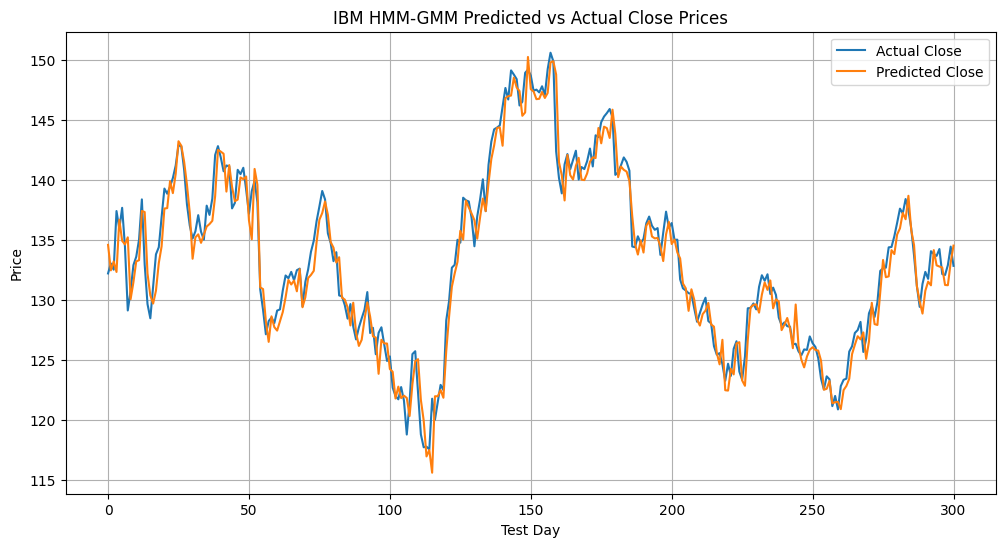

In [23]:
df = load_stock_data()
print("Loading data done")
len_data = len(df)
print(len_data)
train_df = df.iloc[:int(0.98*len_data)]
test_df = df.iloc[int(0.98*len_data):]
print(len(test_df))

X, lengths, scaler = prepare_sequences_real(train_df, window=10)
print("Preparation of sequences done")
model = train_hmm(X, lengths)
print("Training done")

predicted_close = []
actual_close = []
open_prices = []

window = 9  # history length
test_features = test_df[['frac_change', 'frac_high', 'frac_low']].values
test_features_scaled = scaler.transform(test_features)

for i in tqdm(range(window, len(test_df))):
    history = test_features_scaled[i-window:i]
    pred = predict_next_obs(model, history, scaler)
    if pred is not None:
        # Approximate the closing price using: close = open * (1 + frac_change)
        predicted_close_price = test_df['Open'].iloc[i] * (1 + pred[0])
        predicted_close.append(predicted_close_price)
        actual_close.append(test_df['Close'].iloc[i])
        open_prices.append(test_df['Open'].iloc[i])

print("Prediction done")

# Evaluation
mape, dpa = evaluate_predictions(predicted_close, actual_close, open_prices)
print(f"\nMAPE: {mape:.2f}%")
print(f"DPA : {dpa:.2f}%")

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(actual_close, label='Actual Close')
plt.plot(predicted_close, label='Predicted Close')
plt.title("IBM HMM-GMM Predicted vs Actual Close Prices")
plt.xlabel('Test Day')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()